In [1]:
import numpy as np
import pandas as pd

import scarf

scarf.configure_output(level="WARNING", progress=False)

dataset = scarf.cytebase.connect("scarf_docs").download_dataset(
    "tenx_5K_pbmc_rnaseq",
    destination="scarf_datasets",
    zarr=True,
)
ds = scarf.DataStore(f"{dataset}/data.zarr", nthreads=4)
run = ds.pipeline.open(label="docs_default")
clusters = run["clusters"]
markers = run["markers"]
cluster_values = np.asarray(run.cells.fetch("clusters"))

In [2]:
group_id = pd.Series(cluster_values).value_counts().index[0]
group_markers = ds.get_markers(
    marker=markers,
    group_id=group_id,
    min_score=-1,
    min_frac_exp=-1,
)
group_markers[
    [
        "feature_name",
        "score",
        "frac_exp",
        "fold_change",
        "auc",
        "p_value",
        "p_value_adjusted",
    ]
].head(12)

,feature_name,score,frac_exp,fold_change,auc,p_value,p_value_adjusted
0,ADTRP,0.61890,0.23932,14.40724,0.60920,3.580369e-108,6.286828e-106
1,ANKRD55,0.55384,0.14907,18.15077,0.56983,6.599844e-73,5.871235e-71
2,FHIT,0.51857,0.61805,9.98009,0.77473,3.305650e-282,3.695496e-279
3,TSHZ2,0.48540,0.32393,6.24771,0.63679,6.612532e-118,1.327971e-115
4,TCEA3,0.48253,0.21112,7.64557,0.59006,2.671241e-75,2.509470e-73
5,AC005842.1,0.47176,0.16116,8.76196,0.57096,8.924564e-64,6.520959e-62
6,CHRM3-AS2,0.46413,0.38114,7.60798,0.66321,7.806746e-146,2.218836e-143
7,CMTM8,0.43859,0.30379,4.91709,0.61914,1.037609e-85,1.298483e-83
8,EPHX2,0.43070,0.38920,6.87740,0.66277,6.659238e-138,1.731299e-135
9,DPYSL4,0.42810,0.10234,19.18164,0.54824,3.127083e-51,1.659432e-49


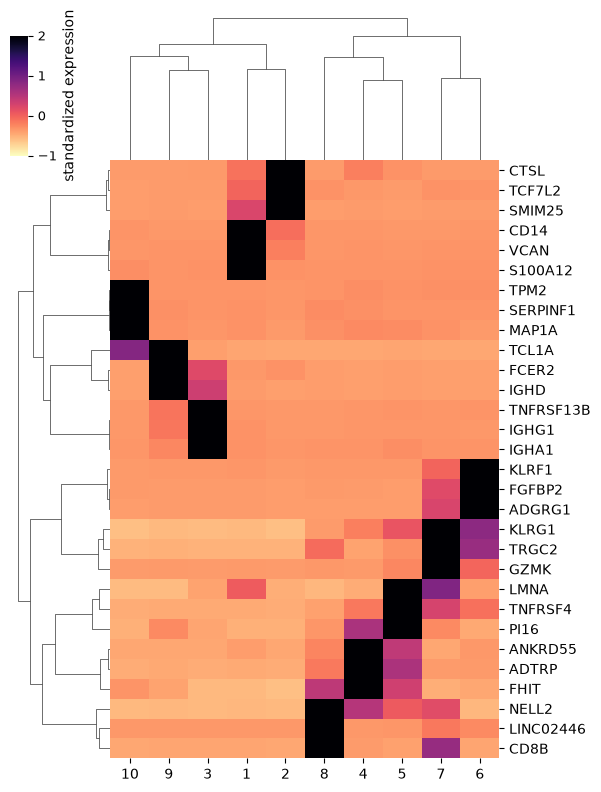

In [3]:
ds.plots.marker_heatmap(
    marker=markers,
    topn=3,
    figsize=(6, 8),
)

In [4]:
label_map = {
    "1": "CD14 monocytes",
    "2": "FCGR3A monocytes",
    "3": "B cells",
    "4": "T cells",
    "5": "NK cells",
    "6": "T cells",
    "7": "T cells",
    "8": "B cells",
    "9": "T cells",
    "10": "pDC-like cells",
}
observed = {str(value) for value in np.unique(cluster_values)}
assert observed == set(label_map)

analysis_cells = np.asarray(run.cells.fetch_all("I"), dtype=bool)
cell_type = np.full(len(analysis_cells), "Not analyzed", dtype=object)
cell_type[analysis_cells] = [label_map[str(value)] for value in cluster_values]
ds.cells.insert("reviewed_cell_type", cell_type, overwrite=True)
pd.Series(cell_type[analysis_cells]).value_counts()

T cells             2368
CD14 monocytes       716
NK cells             434
B cells              390
FCGR3A monocytes      25
pDC-like cells        15
Name: count, dtype: int64

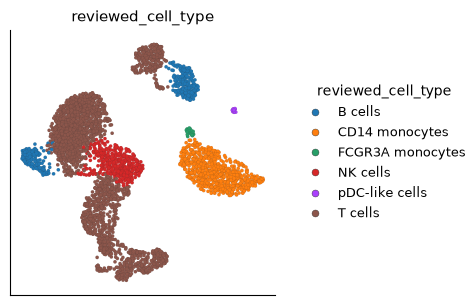

In [5]:
ds.plots.embedding(
    layout=run["umap"],
    color_by="reviewed_cell_type",
    legend_loc="right",
)